## Coverage calculations

All files on farm in `/home/ctbrown/scratch3/2025-workflow-core99/`

In [1]:
# base checkout of workflow directory is here:
BASE='/home/ctbrown/scratch3/2025-workflow-core99/'

# outputs from running `do_mapping`:
BASE_OUTPUTS=BASE+'/outputs.mapping/bams.cds.rand'

# where to place figures
FIG_OUT=BASE+'/outputs.figures/'

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import scipy
import math
import sourmash
import collections

import seaborn as sns
from matplotlib.legend_handler import HandlerTuple

In [3]:
NAMES = [ x.strip() for x in open(BASE+'/inputs.cds/names-plus.list') ]
print(f'loaded {len(NAMES)} species names')

SPECIAL = [ x.strip() for x in open(BASE+'/inputs.cds/names.list') ]
print(f'loaded {len(NAMES)} special species names')

NAMES.sort()
NAMES

loaded 27 species names
loaded 27 special species names


['s__Bariatricus sp004560705',
 's__Bifidobacterium thermacidophilum',
 's__Blautia_A sp945872375',
 's__CAG-269 sp014846485',
 's__CAG-465 sp000433755',
 's__CAG-873 sp016302215',
 's__Colivicinus sp002299675',
 's__Cryptobacteroides sp000432655',
 's__Cryptobacteroides sp000434935',
 's__Cryptobacteroides sp034089285',
 's__Cryptobacteroides sp900546925',
 's__Fimisoma sp002320005',
 's__Floccifex porci',
 's__JAFBIX01 sp021531895',
 's__Lactobacillus amylovorus',
 's__Mogibacterium_A kristiansenii',
 's__Ornithospirochaeta sp022785155',
 's__Phascolarctobacterium_A succinatutens_B',
 's__Prevotella sp000434975',
 's__Prevotella sp002251295',
 's__Ruminococcoides sp902766885',
 's__Ruminococcus_C sp000433635',
 's__SIG351 sp945918795',
 's__Sodaliphilus sp004557565',
 's__UBA2868 sp004552595',
 's__UMGS1225 sp034086705',
 's__Ventricola sp017937505']

In [4]:
XX_NAMES=(             's__Cryptobacteroides sp900546925',
             's__Phascolarctobacterium_A succinatutens',
             's__Mogibacterium_A kristiansenii',
             's__Prevotella sp002251295',)

## Load manysearch of all species against 3,216 metagenomes

& rename columns etc etc.

In [5]:
manysearch_df = pl.read_parquet('../outputs.cds/cds3.bak/manysearch.3216.parquet').with_columns(
    pl.col("query_name").alias("species"),
    pl.col("match_name").alias("metag"),
    (pl.col("intersect_hashes") * pl.col("scaled") / pl.col("containment")).alias("sketch_size"),
)


In [6]:
manysearch_df

query_name,query_md5,match_name,containment,intersect_hashes,ksize,scaled,moltype,match_md5,jaccard,max_containment,average_abund,median_abund,std_abund,query_containment_ani,match_containment_ani,average_containment_ani,max_containment_ani,n_weighted_found,total_weighted_hashes,species,metag,sketch_size
str,str,str,f64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,str,f64
"""s__Prevotella sp002251295""","""11c2f06bb0ba002567a1bdc2a57126…","""SRR11126108""",0.102068,528,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.001608,0.102068,1.738636,1.0,1.099183,0.897025,0.736655,0.81684,0.897025,918,906559,"""s__Prevotella sp002251295""","""SRR11126108""",5.173e6
"""s__UMGS1225 sp034086705""","""32711230ebb0936ab57ed263368289…","""SRR11126108""",0.016775,18,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.000055,0.016775,1.222222,1.0,0.41574,0.823115,0.627176,0.725146,0.823115,22,906559,"""s__UMGS1225 sp034086705""","""SRR11126108""",1.073e6
"""s__Mogibacterium_A kristiansen…","""a6063c0962c975db514497f271511e…","""SRR11126108""",0.101576,303,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.000928,0.101576,2.894389,2.0,1.912803,0.896818,0.717428,0.807123,0.896818,877,906559,"""s__Mogibacterium_A kristiansen…","""SRR11126108""",2.983e6
"""s__JAFBIX01 sp021531895""","""2902fdae1da9e7a10d826eac534864…","""SRR11126108""",0.073482,207,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.000634,0.073482,1.294686,1.0,0.719044,0.883098,0.704529,0.793813,0.883098,268,906559,"""s__JAFBIX01 sp021531895""","""SRR11126108""",2.817e6
"""s__Phascolarctobacterium_A suc…","""b8c6bbf9560cfc087687eb69f00b1c…","""SRR11126108""",0.171033,235,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.000724,0.171033,3.370213,2.0,2.797257,0.919348,0.708798,0.814073,0.919348,792,906559,"""s__Phascolarctobacterium_A suc…","""SRR11126108""",1.374e6
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""s__Roseburia inulinivorans""","""f2654d4c2e0a7a74479c509794d10f…","""ERR8314759""",0.037142,261,21,1000,"""DNA""","""33d0f71a1bb5d8498cce56b97b5b72…",0.000095,0.037142,3.56705,1.0,10.879359,0.854867,0.643489,0.749178,0.854867,931,9259617,"""s__Roseburia inulinivorans""","""ERR8314759""",7.027e6
"""s__CAG-269 sp014846485""","""078c4569f257f75356832c47c16808…","""ERR8314759""",0.009174,4,21,1000,"""DNA""","""33d0f71a1bb5d8498cce56b97b5b72…",0.000001,0.009174,1.5,1.5,0.5,0.799797,0.527391,0.663594,0.799797,6,9259617,"""s__CAG-269 sp014846485""","""ERR8314759""",436000.0
"""s__Phascolarctobacterium_A suc…","""8c3d1fa61d73093ded0c14d4577909…","""ERR8314759""",0.010504,45,21,1000,"""DNA""","""33d0f71a1bb5d8498cce56b97b5b72…",0.000016,0.010504,1.711111,1.0,1.360102,0.804969,0.591817,0.698393,0.804969,77,9259617,"""s__Phascolarctobacterium_A suc…","""ERR8314759""",4.284e6


## Convert columns from hashes into bp

In [7]:
manysearch_df = manysearch_df.with_columns(
    (pl.col('intersect_hashes')*1000).alias('intersect_bp'),
    (pl.col('n_weighted_found')*1000).alias('weighted_bp'),
)

## Build a basic coverage curve function

$$y = G (1 - e^{(-Cx)})$$

G is the genome size, C is the coverage exponent.

In [8]:
def coverage_curve(x, G, C):
    return G*(1 - np.exp(-C*x))

Text(0.5, 1.0, 'example coverage curve')

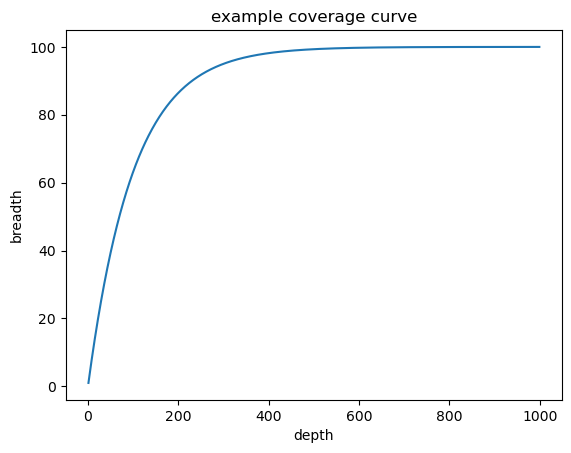

In [9]:
x = np.arange(1, 1000)
y = [ coverage_curve(xx, 100, .01) for xx in x ]
plt.plot(x, y)
plt.xlabel('depth')
plt.ylabel('breadth')
plt.title("example coverage curve")

## Build a fit function that takes weighted bp (x) and containment (y) and fits to a coverage curve

In [10]:
def do_fit(contain_df, *, fn=coverage_curve, p0=None):
    "Fit to given function, which takes two parameters, G and C. Return fit values & params."
    if p0 is None:
        p0 = (max(contain_df['weighted_bp']), .001)
    popt, pcov = scipy.optimize.curve_fit(fn, contain_df['weighted_bp'], contain_df['intersect_bp'], p0)
    G, C = popt

    y = np.asarray(contain_df['weighted_bp'])
    yfit = coverage_curve(y, G, C)

    # residual sum of squares
    ss_res = np.sum((y - yfit) ** 2)
    # total sum of squares
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    # r-squared
    r2 = 1 - (ss_res / ss_tot)

    return yfit, (G, C), r2

fitting for: s__Bariatricus sp004560705
fit params for s__Bariatricus sp004560705: G=1043049 C=6.186134958624553e-07; r2=-0.104


/group/datalabgrp/ctbrown/2025-grist-annie/.snakemake/conda/ab4c18c32e39b7f9ba11a10bc8c18bcf_/lib/python3.12/site-packages/polars/series/series.py:1571: RuntimeWarning: overflow encountered in exp
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),
/group/datalabgrp/ctbrown/2025-grist-annie/.snakemake/conda/ab4c18c32e39b7f9ba11a10bc8c18bcf_/lib/python3.12/site-packages/polars/series/series.py:1571: RuntimeWarning: overflow encountered in multiply
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),


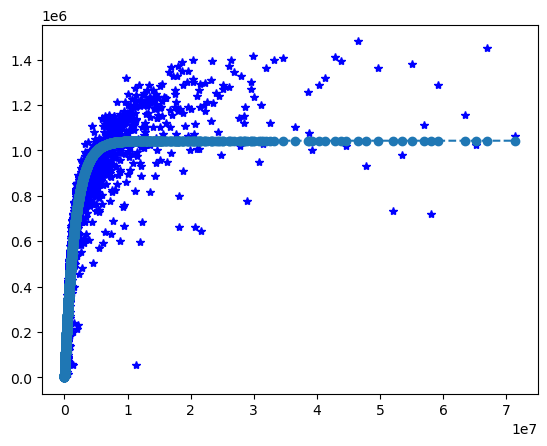

In [11]:
# test fit function!
name = NAMES[0]
print('fitting for:', NAMES[0])
species_df = manysearch_df.filter(pl.col("species") == NAMES[0]).sort(by='weighted_bp')

yfit, (G, C), r2 = do_fit(species_df)
print(f"fit params for {name}: G={G:.0f} C={C}; r2={r2:.3f}")
plt.plot(species_df['weighted_bp'], species_df['intersect_bp'], 'b*')
plt.plot(species_df['weighted_bp'], yfit, 'o--')

## Run fit function for all species, and record parameters.

In [12]:
params_d = {}
params_df = []

for name in NAMES:
    species_df = manysearch_df.filter(pl.col("species") == name)
    yfit, params, r2 = do_fit(species_df)
    (GSIZE, CEXP) = params
    params_d[name] = (GSIZE, CEXP, r2)
    med = np.median(species_df['weighted_bp'] / GSIZE)
    q25 = np.percentile(species_df['weighted_bp'] / GSIZE, .25)
    num_metag = len(species_df.filter(pl.col("intersect_bp") > 20000))
#    print(f"{name:<50} {GSIZE / 1e6:.1f} Mbp    {med:.2f}        {EXP}")
    params_df.append(dict(name=name, med=med, gsize=GSIZE, exp=CEXP, num_metag=num_metag, r2=r2, q25=q25))

params_df = pl.DataFrame(params_df)

ValueError: max() iterable argument is empty

In [13]:
print(name)

s__Colivicinus sp002299675


In [ ]:
print("species                                     med cov       q25           gsize")
for row in params_df.sort(by='med').iter_rows(named=True):
    name, med, gsize, num_metag, r2, q25 = row["name"], row["med"], row["gsize"], row["num_metag"], row["r2"], row['q25']
    print(f"{name:<45} {med:<10.2f}  {q25:<10.4f}   {gsize/1e6:.1f}Mbp     in {num_metag}    {r2:.3f}")

## Update with a new fit function that we have an estimated genome size

We can now adjust 'x' by the estimated size of the (pan) genome, for each species.

Read through [the inStrain docs](https://instrain.readthedocs.io/en/latest/important_concepts.html) for some interesting context -
the coverage parameter should be ~0.88 for a full genome.

In [ ]:
# try with adjusted coverage, where we divide 'x' by tbe estimated genome size
params2_d = {}
for name in NAMES:
    species_df = manysearch_df.filter(pl.col("species") == name)
    GSIZE, EXP, r2 = params_d[name]

    def adj_coverage_curve(x, c, e):
        return c*(1 - np.exp(-e*x/GSIZE))

    p0 = (max(species_df['weighted_bp']), 0.9)
    _, params2, _ = do_fit(species_df, fn=adj_coverage_curve, p0=p0)
    NORM, EXP2 = params2
    print(f"{name:<50} {NORM:<10.0f} {EXP2:2f}")
    params2_d[name] = params2

In [ ]:
# use the new information to estimate breadth and depth for every row, and then add into data frame.
adj_df = []

for row in manysearch_df.iter_rows(named=True):
    species = row["species"]
    metag = row["metag"]
    intersect_bp = row["intersect_bp"]
    weighted_bp = row["weighted_bp"]
    GSIZE, EXP, r2 = params_d[species]
    breadth = intersect_bp / GSIZE
    depth = weighted_bp / GSIZE
    fit_breadth = coverage_curve(weighted_bp, GSIZE, EXP) / GSIZE
    adj_df.append(dict(species=species, metag=metag, breadth=breadth, depth=depth, fit_breadth=fit_breadth))

adj_df = pl.DataFrame(adj_df)
join_df = manysearch_df.join(adj_df, on=['species', 'metag'], how='inner')
join_df

In [ ]:
for name in NAMES:
    species_df = join_df.filter(pl.col("species") == name)

    plt.plot(species_df['depth'], species_df['breadth'], '*', label='data')
    plt.plot(species_df['depth'], species_df['fit_breadth'], '*', alpha=0.5, label='fit')
    plt.tight_layout()
    if name in SPECIAL:
        plt.title('**' + name)
    else:
        plt.title(name)
    plt.xlabel('depth (coverage)')
    plt.ylabel('breadth (detection)')
    plt.legend(loc='lower right')

    #plt.xlim(0, 3)
    #plt.ylim(0, 1.5)
    plt.show()


In [ ]:
for name in NAMES:
    species_df = join_df.filter(pl.col("species") == name)
    GSIZE, EXP, r2 = params_d[name]

    plt.plot(species_df['weighted_bp'] / GSIZE, species_df['intersect_bp'] / GSIZE, '*')
    plt.tight_layout()
    if name in SPECIAL:
        plt.title('**' + name)
    else:
        plt.title(name)
    plt.xlabel('coverage-ish')
    plt.ylabel('isect k-mers')

    yfit = coverage_curve(species_df['weighted_bp'], GSIZE, EXP)
    plt.plot(species_df['weighted_bp'] / GSIZE, yfit / GSIZE, 'o', alpha=0.5)
    plt.xlim(0, 3)
    plt.show()


### Export / save k-mer coverage information

In [ ]:
join_df.write_csv('../outputs.cds/kmer-coverage.csv')

## Can we correlate with metagenome sequencing depth?

Answer: no, not really. Presumably biology is involved (that is, actual abundance of microbes is different in different metagenomes!)

In [ ]:
metadata_df = pl.scan_parquet('/group/ctbrowngrp5/sra-metagenomes/20241128-metadata.parquet')
metadata_df = metadata_df.select(["acc", "organism", "assay_type", "mbases"])\
    .filter(pl.col("acc") != "NP")\
    .filter(pl.col("assay_type") == "WGS")

metadata_df = metadata_df.collect()
metadata_df

In [ ]:
for name in sorted(NAMES):
    species_df = join_df.filter(pl.col("species") == name)
    foo_df = species_df.join(metadata_df, left_on='metag', right_on='acc', how='inner')
    plt.plot(foo_df['depth'], foo_df['mbases'], '*', alpha=0.5)
    plt.xlabel('predicted coverage (depth)')
    plt.ylabel('mbases sequenced')
    plt.tight_layout()
    if name in SPECIAL:
        plt.title('**' + name)
    else:
        plt.title(name)
    plt.xlim(0, 20)
    plt.show()